# Titanic – Pipeline final – John Bouckaert & Hugo Fiévet

## Introduction

Dans ce notebook final, nous construisons un pipeline complet pour prédire la survie des passagers du Titanic.

Ce travail reprend les différentes étapes réalisées dans les notebooks précédents :
- l’analyse exploratoire du dataset ;
- le prétraitement des données ;
- la sélection de variables ;
- la comparaison de plusieurs modèles de machine learning.

Après comparaison des différents résultats, nous avons choisi de retenir la combinaison **SelectKBest + Decision Tree**, car c’est celle qui a obtenu le meilleur F1-score sur le jeu de test.

L’objectif de ce notebook est donc de regrouper tout le processus dans un seul pipeline, depuis le dataset brut jusqu’à l’évaluation finale du modèle.

## 1. Chargement des librairies

Dans cette première étape, nous importons les librairies nécessaires pour charger les données, les prétraiter, construire le pipeline et évaluer le modèle.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt

## 2. Chargement du dataset

Nous commençons par charger le fichier brut du Titanic.  
Contrairement aux notebooks précédents, nous ne partons pas des fichiers déjà prétraités comme `xtrain.csv` ou `xtrain_KB.csv`.

Ici, l’objectif est de construire un pipeline complet, donc nous repartons directement du dataset original.

In [2]:
df = pd.read_csv("Titanic Dataset.csv")

print("Dimensions du dataset :", df.shape)
print("\nAperçu des premières lignes :")
display(df.head())

print("\nColonnes disponibles :")
print(df.columns.tolist())

Dimensions du dataset : (1309, 11)

Aperçu des premières lignes :


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S



Colonnes disponibles :
['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked']


## 3. Séparation entre les variables explicatives et la variable cible

La variable que nous voulons prédire est `survived`.

Nous séparons donc le dataset en deux parties :
- `X`, qui contient les variables explicatives ;
- `y`, qui contient la variable cible.

In [3]:
target = "survived"

X = df.drop(columns=[target])
y = df[target]

print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

print("\nRépartition de la variable cible :")
print(y.value_counts(normalize=True).round(3))

Dimensions de X : (1309, 10)
Dimensions de y : (1309,)

Répartition de la variable cible :
survived
0    0.618
1    0.382
Name: proportion, dtype: float64


## 4. Séparation en jeu d'entraînement et jeu de test

Comme dans les notebooks précédents, nous utilisons une séparation train/test avec `random_state=42` afin d’obtenir des résultats reproductibles.

Nous utilisons aussi `stratify=y`, car la variable cible n’est pas parfaitement équilibrée.  
Cela permet de garder une proportion similaire de survivants et de non-survivants dans le jeu d’entraînement et dans le jeu de test.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Dimensions de X_train :", X_train.shape)
print("Dimensions de X_test :", X_test.shape)
print("Dimensions de y_train :", y_train.shape)
print("Dimensions de y_test :", y_test.shape)

print("\nRépartition de y_train :")
print(y_train.value_counts(normalize=True).round(3))

print("\nRépartition de y_test :")
print(y_test.value_counts(normalize=True).round(3))

Dimensions de X_train : (1047, 10)
Dimensions de X_test : (262, 10)
Dimensions de y_train : (1047,)
Dimensions de y_test : (262,)

Répartition de y_train :
survived
0    0.618
1    0.382
Name: proportion, dtype: float64

Répartition de y_test :
survived
0    0.618
1    0.382
Name: proportion, dtype: float64


## 5. Feature engineering

Dans les notebooks précédents, nous avons vu que certaines variables brutes pouvaient être transformées pour créer des informations plus utiles pour le modèle.

Nous reprenons ici les mêmes transformations que dans le notebook de preprocessing :

- extraction du titre à partir de la variable `name` ;
- regroupement des titres rares dans une catégorie `Other` ;
- création de `has_cabin` pour savoir si une cabine est renseignée ;
- création de `family_size` à partir de `sibsp` et `parch` ;
- création de `family_group` pour distinguer les passagers seuls, les petites familles et les grandes familles.

Ces transformations sont placées dans une classe afin de pouvoir les intégrer proprement dans le pipeline final.

In [5]:
class TitanicFeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Cette classe reprend le feature engineering réalisé dans le notebook de preprocessing.
    Elle permet de créer de nouvelles variables à partir des colonnes brutes du dataset Titanic.
    """

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # 1. Extraction du titre à partir du nom
        X["title"] = X["name"].str.extract(r",\s*([^\.]+)\.", expand=False)

        # 2. Regroupement des titres rares
        common_titles = ["Mr", "Mrs", "Miss", "Master"]
        X["title_grouped"] = X["title"].apply(
            lambda x: x if x in common_titles else "Other"
        )

        # 3. Création d'une variable indiquant si la cabine est renseignée
        X["has_cabin"] = X["cabin"].notna().astype(int)

        # 4. Création de la taille de la famille
        X["family_size"] = X["sibsp"] + X["parch"] + 1

        # 5. Regroupement de la taille de la famille
        def group_family_size(size):
            if size == 1:
                return "alone"
            elif 2 <= size <= 4:
                return "small_family"
            else:
                return "large_family"

        X["family_group"] = X["family_size"].apply(group_family_size)

        # 6. Suppression des colonnes brutes devenues inutiles
        columns_to_drop = ["name", "title", "ticket", "cabin"]
        X = X.drop(columns=columns_to_drop, errors="ignore")

        return X

Nous vérifions maintenant que la classe fonctionne correctement sur le jeu d'entraînement.

Cette vérification est importante avant de l’intégrer dans le pipeline complet, car elle permet de s’assurer que les nouvelles variables sont bien créées et que les colonnes brutes inutiles sont bien supprimées.

In [6]:
feature_engineer = TitanicFeatureEngineer()

X_train_fe = feature_engineer.fit_transform(X_train)

print("Dimensions après feature engineering :", X_train_fe.shape)

print("\nColonnes obtenues après feature engineering :")
print(X_train_fe.columns.tolist())

print("\nAperçu des premières lignes :")
display(X_train_fe.head())

Dimensions après feature engineering : (1047, 11)

Colonnes obtenues après feature engineering :
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'title_grouped', 'has_cabin', 'family_size', 'family_group']

Aperçu des premières lignes :


,pclass,sex,age,sibsp,parch,fare,embarked,title_grouped,has_cabin,family_size,family_group
999,3,female,NaN,0,0,7.7500,Q,Miss,0,1,alone
392,2,female,24.0,1,0,27.7208,C,Mrs,0,2,small_family
628,3,female,11.0,4,2,31.2750,S,Miss,0,7,large_family
1165,3,male,25.0,0,0,7.2250,C,Mr,0,1,alone
604,3,female,16.0,0,0,7.6500,S,Miss,0,1,alone


Après vérification, le feature engineering fonctionne correctement.

Les variables `title_grouped`, `has_cabin`, `family_size` et `family_group` ont bien été créées.  
Les colonnes brutes `name`, `ticket` et `cabin` ont été supprimées, car les informations utiles qu’elles contenaient ont été transformées dans des variables plus exploitables.

Cette étape reprend donc le travail déjà réalisé dans le notebook de preprocessing, mais sous une forme plus adaptée à un pipeline complet.

## 6. Imputation des valeurs manquantes

Dans le notebook de preprocessing, nous avions remarqué que les valeurs manquantes concernaient surtout la variable `age`.

Pour éviter une imputation trop simple, nous avions choisi d’imputer l’âge en utilisant d’abord la médiane par groupe `title_grouped` et `pclass`.  
Cette méthode permet de conserver une certaine cohérence entre le profil du passager et l’âge imputé.

Par exemple, un passager avec le titre `Master` n’a pas le même âge moyen qu’un passager avec le titre `Mr`.

Nous reprenons donc cette logique dans une classe compatible avec un pipeline.

Pour les autres variables :
- `fare` est imputée avec la médiane du jeu d’entraînement ;
- `embarked` est imputée avec le mode du jeu d’entraînement.

In [7]:
class TitanicMissingValueImputer(BaseEstimator, TransformerMixin):
    """
    Cette classe reprend la stratégie d'imputation utilisée dans le notebook de preprocessing.

    - age : imputation par médiane selon title_grouped et pclass
    - fare : imputation par médiane
    - embarked : imputation par mode
    """

    def fit(self, X, y=None):
        X = X.copy()

        # Médianes d'âge par groupe
        self.age_medians_by_group_ = X.groupby(
            ["title_grouped", "pclass"]
        )["age"].median()

        # Médianes de secours par titre
        self.age_medians_by_title_ = X.groupby("title_grouped")["age"].median()

        # Médiane globale de secours
        self.age_median_global_ = X["age"].median()

        # Imputation des autres variables
        self.fare_median_ = X["fare"].median()
        self.embarked_mode_ = X["embarked"].mode()[0]

        return self

    def transform(self, X):
        X = X.copy()

        def impute_age(row):
            if pd.notna(row["age"]):
                return row["age"]

            group_key = (row["title_grouped"], row["pclass"])

            if (
                group_key in self.age_medians_by_group_.index
                and pd.notna(self.age_medians_by_group_.loc[group_key])
            ):
                return self.age_medians_by_group_.loc[group_key]

            if (
                row["title_grouped"] in self.age_medians_by_title_.index
                and pd.notna(self.age_medians_by_title_.loc[row["title_grouped"]])
            ):
                return self.age_medians_by_title_.loc[row["title_grouped"]]

            return self.age_median_global_

        X["age"] = X.apply(impute_age, axis=1)

        X["fare"] = X["fare"].fillna(self.fare_median_)
        X["embarked"] = X["embarked"].fillna(self.embarked_mode_)

        return X

Nous testons maintenant cette classe sur le jeu d'entraînement après le feature engineering.

Le but est simplement de vérifier qu'il ne reste plus de valeurs manquantes avant de passer à l'encodage et à la standardisation.

In [8]:
missing_value_imputer = TitanicMissingValueImputer()

X_train_imputed = missing_value_imputer.fit_transform(X_train_fe)

print("Valeurs manquantes après imputation :")
print(X_train_imputed.isna().sum())

print("\nAperçu des données après imputation :")
display(X_train_imputed.head())

Valeurs manquantes après imputation :
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
title_grouped    0
has_cabin        0
family_size      0
family_group     0
dtype: int64

Aperçu des données après imputation :


,pclass,sex,age,sibsp,parch,fare,embarked,title_grouped,has_cabin,family_size,family_group
999,3,female,18.0,0,0,7.7500,Q,Miss,0,1,alone
392,2,female,24.0,1,0,27.7208,C,Mrs,0,2,small_family
628,3,female,11.0,4,2,31.2750,S,Miss,0,7,large_family
1165,3,male,25.0,0,0,7.2250,C,Mr,0,1,alone
604,3,female,16.0,0,0,7.6500,S,Miss,0,1,alone


Après cette étape, les valeurs manquantes ont bien été traitées.

L'âge a été imputé avec une méthode plus précise qu'une simple médiane globale, car elle tient compte du titre du passager et de sa classe.  
Cette logique reprend directement celle utilisée dans notre notebook de preprocessing.

Le dataset est maintenant complet, mais il contient encore des variables catégorielles sous forme de texte.  
Nous devons donc les encoder pour pouvoir les utiliser dans le modèle.

### Justification de l'imputation choisie par rapport à `SimpleImputer`

`sklearn` propose une méthode d'imputation standard avec `SimpleImputer`.  
Cette méthode est très utile pour remplacer les valeurs manquantes par une statistique simple, par exemple :

- la médiane globale pour une variable numérique ;
- la valeur la plus fréquente pour une variable catégorielle.

Dans notre cas, nous aurions donc pu utiliser une imputation de type médiane globale pour `age`.  
Cependant, cette solution aurait été moins précise, car elle aurait attribué la même valeur de remplacement à tous les passagers sans tenir compte de leur profil.

Nous avons donc conservé une imputation personnalisée compatible avec un pipeline `sklearn`.  
Elle reste plus adaptée au dataset Titanic, car l'âge est imputé en priorité selon le titre du passager et sa classe (`title_grouped` + `pclass`).  
Cela permet par exemple de ne pas traiter un enfant avec le titre `Master` comme un adulte avec le titre `Mr`.

Notre méthode garde donc l'esprit d'une imputation `sklearn`, puisqu'elle est intégrée dans une classe `BaseEstimator` / `TransformerMixin`, mais elle est plus spécifique et plus cohérente avec les observations faites pendant le preprocessing.

## 7. Encodage des variables catégorielles et standardisation

Dans le notebook de preprocessing, les variables catégorielles avaient été transformées avec `get_dummies`.

Dans le pipeline final, nous utilisons `OneHotEncoder`, qui réalise le même type de transformation mais de manière plus adaptée à un pipeline `sklearn`.

Les variables catégorielles encodées sont les mêmes que dans notre travail précédent :

- `pclass`
- `sex`
- `embarked`
- `title_grouped`
- `family_group`

Les variables numériques standardisées sont également les mêmes :

- `age`
- `fare`
- `sibsp`
- `parch`
- `family_size`

La variable `has_cabin` est déjà binaire, donc nous la conservons telle quelle.

In [9]:
categorical_columns = [
    "pclass",
    "sex",
    "embarked",
    "title_grouped",
    "family_group"
]

numerical_columns = [
    "age",
    "fare",
    "sibsp",
    "parch",
    "family_size"
]

binary_columns = [
    "has_cabin"
]

try:
    onehot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    onehot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        ("cat", onehot_encoder, categorical_columns),
        ("bin", "passthrough", binary_columns)
    ],
    verbose_feature_names_out=False
)

Nous testons maintenant le préprocesseur complet sur les données déjà passées par le feature engineering et l'imputation.

Normalement, nous devons retrouver 22 variables après encodage, comme dans le notebook de preprocessing.

In [10]:
X_train_preprocessed = preprocessor.fit_transform(X_train_imputed)

feature_names = preprocessor.get_feature_names_out()

X_train_preprocessed_df = pd.DataFrame(
    X_train_preprocessed,
    columns=feature_names,
    index=X_train_imputed.index
)

print("Dimensions après encodage et standardisation :", X_train_preprocessed_df.shape)

print("\nColonnes obtenues :")
print(X_train_preprocessed_df.columns.tolist())

print("\nAperçu des données prétraitées :")
display(X_train_preprocessed_df.head())

Dimensions après encodage et standardisation : (1047, 22)

Colonnes obtenues :
['age', 'fare', 'sibsp', 'parch', 'family_size', 'pclass_1', 'pclass_2', 'pclass_3', 'sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'title_grouped_Master', 'title_grouped_Miss', 'title_grouped_Mr', 'title_grouped_Mrs', 'title_grouped_Other', 'family_group_alone', 'family_group_large_family', 'family_group_small_family', 'has_cabin']

Aperçu des données prétraitées :


,age,fare,sibsp,parch,family_size,pclass_1,pclass_2,pclass_3,sex_female,sex_male,...,embarked_S,title_grouped_Master,title_grouped_Miss,title_grouped_Mr,title_grouped_Mrs,title_grouped_Other,family_group_alone,family_group_large_family,family_group_small_family,has_cabin
999,-0.820265,-0.499246,-0.479571,-0.447597,-0.557940,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
392,-0.371539,-0.090614,0.510785,-0.447597,0.083293,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
628,-1.343779,-0.017890,3.481854,1.872374,3.289456,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1165,-0.296752,-0.509988,-0.479571,-0.447597,-0.557940,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
604,-0.969840,-0.501292,-0.479571,-0.447597,-0.557940,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


Après l'encodage et la standardisation, nous obtenons 22 variables explicatives.

Les variables catégorielles ont été transformées en colonnes binaires grâce au OneHotEncoding.  
Les variables numériques ont été standardisées afin d'être sur une même échelle.

Même si le modèle final retenu est un arbre de décision, nous conservons cette standardisation car elle faisait partie du preprocessing commun utilisé dans nos comparaisons précédentes, notamment pour pouvoir comparer correctement plusieurs modèles comme KNN, Random Forest et Decision Tree.

Le prétraitement est maintenant complet.  
L'étape suivante consiste à ajouter la sélection de variables avec `SelectKBest`, puisque c'est cette méthode qui a donné les meilleurs résultats avec le modèle Decision Tree.

## 8. Sélection des variables avec SelectKBest

Dans notre travail précédent, nous avions testé plusieurs méthodes de sélection de variables :

- sélection personnelle ;
- Variance Threshold ;
- SelectKBest.

Après comparaison des modèles, la combinaison qui a donné le meilleur résultat est **SelectKBest + Decision Tree**.

Nous reprenons donc ici `SelectKBest` avec `k=15`, comme dans notre notebook de modélisation.  
L’objectif est de garder les 15 variables les plus pertinentes pour prédire la survie des passagers.

In [11]:
selector = SelectKBest(score_func=f_classif, k=15)

X_train_selected = selector.fit_transform(X_train_preprocessed_df, y_train)

selected_features = X_train_preprocessed_df.columns[selector.get_support()]

print("Dimensions avant SelectKBest :", X_train_preprocessed_df.shape)
print("Dimensions après SelectKBest :", X_train_selected.shape)

print("\nVariables sélectionnées :")
for feature in selected_features:
    print("-", feature)

Dimensions avant SelectKBest : (1047, 22)
Dimensions après SelectKBest : (1047, 15)

Variables sélectionnées :
- fare
- parch
- pclass_1
- pclass_3
- sex_female
- sex_male
- embarked_C
- embarked_S
- title_grouped_Miss
- title_grouped_Mr
- title_grouped_Mrs
- family_group_alone
- family_group_large_family
- family_group_small_family
- has_cabin


Après l'application de `SelectKBest`, nous passons de 22 variables à 15 variables.

Cette étape permet de supprimer certaines variables moins utiles pour le modèle.  
Dans notre cas, cette méthode de sélection a donné les meilleurs résultats lorsqu'elle était combinée avec un arbre de décision.

Nous allons donc maintenant utiliser ces variables sélectionnées pour entraîner le modèle final.

## 9. Modèle final : Decision Tree

Dans les notebooks de modélisation, nous avons testé plusieurs modèles :

- KNN ;
- Decision Tree ;
- Random Forest.

Après optimisation et comparaison des scores, le modèle retenu est le **Decision Tree** combiné avec `SelectKBest`.

Nous utilisons ici les meilleurs paramètres obtenus dans le notebook `Titanic_Model_KB_DT.ipynb`.

In [12]:
final_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=42
)

final_model.fit(X_train_selected, y_train)


,criterion,'entropy'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Le modèle final est maintenant entraîné sur les variables sélectionnées.

Cependant, à ce stade, nous avons encore réalisé les étapes séparément pour vérifier que tout fonctionne correctement.

L’objectif final est maintenant de regrouper toutes ces étapes dans un seul pipeline complet :
- feature engineering ;
- imputation ;
- encodage ;
- standardisation ;
- sélection de variables ;
- modèle final.

## 10. Création du pipeline final complet

Maintenant que chaque étape a été vérifiée séparément, nous pouvons construire le pipeline final.

Ce pipeline reprend toutes les étapes importantes du travail :

1. feature engineering ;
2. imputation des valeurs manquantes ;
3. encodage des variables catégorielles ;
4. standardisation des variables numériques ;
5. sélection des variables avec `SelectKBest` ;
6. entraînement du modèle final avec `DecisionTreeClassifier`.

L'intérêt du pipeline est de regrouper tout le processus dans un seul objet.  
Cela rend le code plus propre, plus lisible et plus proche d'une vraie utilisation en machine learning.

In [13]:
# Recréation propre du préprocesseur pour le pipeline final

try:
    onehot_encoder_final = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    onehot_encoder_final = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

preprocessor_final = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        ("cat", onehot_encoder_final, categorical_columns),
        ("bin", "passthrough", binary_columns)
    ],
    verbose_feature_names_out=False
)

In [14]:
final_pipeline = Pipeline(
    steps=[
        ("feature_engineering", TitanicFeatureEngineer()),
        ("missing_values", TitanicMissingValueImputer()),
        ("preprocessing", preprocessor_final),
        ("selection", SelectKBest(score_func=f_classif, k=15)),
        ("model", DecisionTreeClassifier(
            criterion="entropy",
            max_depth=3,
            min_samples_leaf=1,
            min_samples_split=2,
            random_state=42
        ))
    ]
)

final_pipeline

,steps,"[('feature_engineering', ...), ('missing_values', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


Nous pouvons maintenant entraîner le pipeline complet directement sur les données brutes du jeu d'entraînement.

C'est une étape importante, car cela montre que le pipeline est bien capable de partir des données originales, sans utiliser les fichiers intermédiaires créés dans les notebooks précédents.

In [15]:
final_pipeline.fit(X_train, y_train)

print("Pipeline final entraîné avec succès.")

Pipeline final entraîné avec succès.


Le pipeline final est maintenant entraîné.

Il contient bien toutes les étapes du projet :
- transformation des variables brutes ;
- traitement des valeurs manquantes ;
- encodage et standardisation ;
- sélection des meilleures variables ;
- modèle final.

La prochaine étape consiste à évaluer ce pipeline sur le jeu de test afin de vérifier ses performances finales.

## 11. Évaluation du pipeline final

Maintenant que le pipeline complet est entraîné, nous pouvons l'évaluer sur le jeu de test.

Cette étape permet de vérifier les performances du modèle sur des données qu'il n'a pas vues pendant l'entraînement.

Nous utilisons les mêmes métriques que dans les notebooks précédents :

- l'accuracy ;
- le F1-score ;
- la matrice de confusion ;
- le rapport de classification.

In [16]:
y_pred = final_pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy du pipeline final :", round(accuracy, 4))
print("F1-score du pipeline final :", round(f1, 4))

Accuracy du pipeline final : 0.855
F1-score du pipeline final : 0.8


L'accuracy obtenue est de **0.8550**. Cela signifie que le pipeline final prédit correctement environ **85,5 %** des passagers du jeu de test.

Le F1-score obtenu est de **0.8000**. Cette métrique est importante ici, car elle tient compte à la fois de la précision et du rappel pour la classe `survived = 1`, c'est-à-dire les passagers survivants.

Ces deux scores montrent que le modèle donne de bonnes performances sur le jeu de test. L'accuracy est élevée, et le F1-score confirme que le modèle ne se contente pas uniquement de bien prédire la classe majoritaire.

In [17]:
cm = confusion_matrix(y_test, y_pred)

print("Matrice de confusion :")
print(cm)

Matrice de confusion :
[[148  14]
 [ 24  76]]


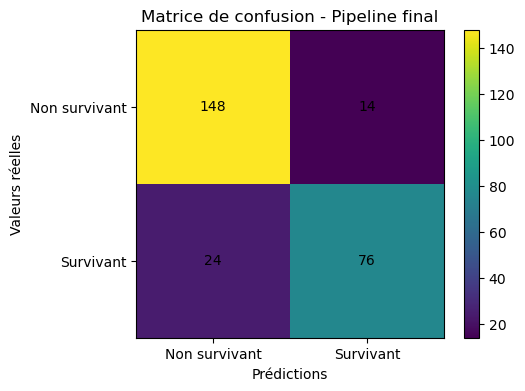

In [18]:
plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Matrice de confusion - Pipeline final")
plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")
plt.xticks([0, 1], ["Non survivant", "Survivant"])
plt.yticks([0, 1], ["Non survivant", "Survivant"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

In [19]:
print("Rapport de classification :")
print(classification_report(y_test, y_pred))

Rapport de classification :
              precision    recall  f1-score   support

           0       0.86      0.91      0.89       162
           1       0.84      0.76      0.80       100

    accuracy                           0.85       262
   macro avg       0.85      0.84      0.84       262
weighted avg       0.85      0.85      0.85       262



La matrice de confusion obtenue est :

- **148** passagers non survivants sont correctement prédits comme non survivants ;
- **14** passagers non survivants sont prédits à tort comme survivants ;
- **24** passagers survivants sont prédits à tort comme non survivants ;
- **76** passagers survivants sont correctement prédits comme survivants.

Le rapport de classification montre que le modèle prédit mieux les **non-survivants** que les **survivants**. Pour la classe `0` non survivant, le rappel est de **0.91**, ce qui signifie que le modèle retrouve 91 % des non-survivants. Pour la classe `1` survivant, le rappel est de **0.76**, ce qui signifie que le modèle retrouve 76 % des survivants.

Le modèle est donc performant, mais il rate encore une partie des survivants : **24 survivants** sont classés à tort comme non-survivants. Cela montre que la prédiction de la survie reste plus difficile que la prédiction de la non-survie.

Le pipeline final reproduit bien la meilleure approche obtenue dans les notebooks précédents, avec une accuracy d'environ **0.8550** et un F1-score de **0.8000**.

### Analyse complémentaire : comparaison train / test

Nous comparons maintenant les performances du pipeline sur le jeu d'entraînement et sur le jeu de test.

Cette comparaison permet de repérer un éventuel surapprentissage.  
Si le score d'entraînement était beaucoup plus élevé que le score de test, cela pourrait indiquer que le modèle apprend trop fortement les données d'entraînement et généralise moins bien sur de nouvelles données.

In [20]:
y_pred_train = final_pipeline.predict(X_train)

accuracy_train = accuracy_score(y_train, y_pred_train)
f1_train = f1_score(y_train, y_pred_train)

train_test_comparison_df = pd.DataFrame({
    "Jeu de données": [
        "Entraînement",
        "Test"
    ],
    "Accuracy": [
        accuracy_train,
        accuracy
    ],
    "F1-score": [
        f1_train,
        f1
    ]
})

display(train_test_comparison_df.round(4))

print("Écart accuracy train - test :", round(accuracy_train - accuracy, 4))
print("Écart F1-score train - test :", round(f1_train - f1, 4))

,Jeu de données,Accuracy,F1-score
0,Entraînement,0.7975,0.7218
1,Test,0.8550,0.8000


Écart accuracy train - test : -0.0574
Écart F1-score train - test : -0.0782


Les résultats train/test obtenus sont les suivants :

- accuracy entraînement : **0.7975** ;
- accuracy test : **0.8550** ;
- F1-score entraînement : **0.7218** ;
- F1-score test : **0.8000**.

Les écarts `train - test` sont négatifs : **-0.0574** pour l'accuracy et **-0.0782** pour le F1-score. Cela signifie que le modèle obtient ici de meilleurs résultats sur le jeu de test que sur le jeu d'entraînement.

Ce résultat ne montre donc **pas de surapprentissage**. En cas de surapprentissage, on s'attendrait plutôt à observer un score d'entraînement nettement supérieur au score de test.

Ici, le jeu de test semble légèrement plus facile à prédire que le jeu d'entraînement. Cela peut arriver avec un dataset relativement petit comme Titanic, selon la manière dont les passagers sont répartis entre le train et le test.

Il faut donc compléter cette analyse avec la validation croisée, qui donne une estimation plus stable des performances du modèle sur plusieurs découpages différents.

## 12. Validation croisée

Pour compléter l'évaluation, nous utilisons aussi une validation croisée sur le jeu d'entraînement.

Cette étape permet d'avoir une idée plus stable des performances du modèle, car il est évalué sur plusieurs découpages différents des données.

Nous utilisons ici le F1-score, car c'est la métrique principale que nous avons utilisée pour comparer les modèles.

In [21]:
cv_scores = cross_val_score(
    final_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

cv_mean = cv_scores.mean()
cv_std = cv_scores.std()

print("Scores F1 obtenus pour chaque fold :")
for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i} : {score:.4f}")

print("\nRésumé de la validation croisée :")
print(f"F1-score moyen en validation croisée : {cv_mean:.4f}")
print(f"Écart-type : {cv_std:.4f}")

print("\nComparaison avec le jeu de test :")
print(f"F1-score sur le jeu de test : {f1:.4f}")
print(f"F1-score moyen en validation croisée : {cv_mean:.4f}")
print(f"Différence absolue : {abs(f1 - cv_mean):.4f}")

Scores F1 obtenus pour chaque fold :
Fold 1 : 0.7607
Fold 2 : 0.7170
Fold 3 : 0.6887
Fold 4 : 0.7500
Fold 5 : 0.6892

Résumé de la validation croisée :
F1-score moyen en validation croisée : 0.7211
Écart-type : 0.0300

Comparaison avec le jeu de test :
F1-score sur le jeu de test : 0.8000
F1-score moyen en validation croisée : 0.7211
Différence absolue : 0.0789


La validation croisée donne les F1-scores suivants : **0.7607**, **0.7170**, **0.6887**, **0.7500** et **0.6892**.

Le F1-score moyen en validation croisée est de **0.7211**, avec un écart-type de **0.0300**. Les résultats varient donc selon les folds, mais restent dans une zone relativement stable, autour de 0.72.

Le F1-score obtenu sur le jeu de test est de **0.8000**, soit **0.0789** au-dessus de la moyenne en validation croisée. Cela montre que le jeu de test donne ici un résultat plus favorable que la moyenne des validations croisées.

Il vaut donc mieux ne pas interpréter uniquement le score test de 0.8000. La validation croisée suggère que la performance réelle du modèle est probablement plus proche d'un F1-score d'environ **0.72** en moyenne.

Le modèle reste correct et stable, mais le score test est un peu optimiste par rapport à la validation croisée.

### Courbe d'apprentissage du pipeline final

Nous ajoutons également une courbe d'apprentissage afin d'observer l'évolution du score lorsque la taille du jeu d'entraînement augmente.

La courbe est calculée sur le pipeline complet, et pas uniquement sur le modèle `DecisionTreeClassifier`.  
Cela signifie que chaque étape est bien prise en compte pendant la validation croisée :

- feature engineering ;
- imputation des valeurs manquantes ;
- encodage et standardisation ;
- sélection de variables ;
- entraînement du modèle.

,Taille entraînement,F1-score entraînement moyen,Écart-type entraînement,F1-score validation moyen,Écart-type validation
0,83,0.7488,0.0887,0.5879,0.0794
1,167,0.7526,0.0185,0.7051,0.0263
2,251,0.7529,0.0146,0.6823,0.0415
3,334,0.7033,0.0481,0.6790,0.0473
4,418,0.7319,0.0109,0.7137,0.0404
5,502,0.7506,0.0106,0.7117,0.0340
6,585,0.7431,0.0145,0.7108,0.0369
7,669,0.7436,0.0112,0.7192,0.0303
8,753,0.7367,0.0121,0.7089,0.0332
9,837,0.7356,0.0132,0.7211,0.0300


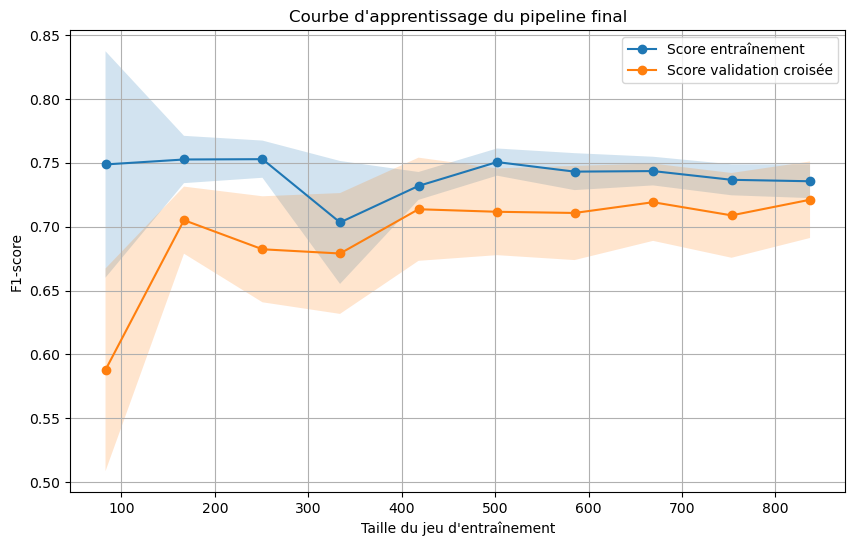

In [22]:
train_sizes, train_scores, validation_scores = learning_curve(
    estimator=final_pipeline,
    X=X_train,
    y=y_train,
    cv=5,
    scoring="f1",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=1
)

train_scores_mean = train_scores.mean(axis=1)
train_scores_std = train_scores.std(axis=1)
validation_scores_mean = validation_scores.mean(axis=1)
validation_scores_std = validation_scores.std(axis=1)

learning_curve_df = pd.DataFrame({
    "Taille entraînement": train_sizes,
    "F1-score entraînement moyen": train_scores_mean,
    "Écart-type entraînement": train_scores_std,
    "F1-score validation moyen": validation_scores_mean,
    "Écart-type validation": validation_scores_std
})

display(learning_curve_df.round(4))

plt.figure(figsize=(10, 6))
plt.plot(
    train_sizes,
    train_scores_mean,
    marker="o",
    label="Score entraînement"
)
plt.plot(
    train_sizes,
    validation_scores_mean,
    marker="o",
    label="Score validation croisée"
)

plt.fill_between(
    train_sizes,
    train_scores_mean - train_scores_std,
    train_scores_mean + train_scores_std,
    alpha=0.2
)
plt.fill_between(
    train_sizes,
    validation_scores_mean - validation_scores_std,
    validation_scores_mean + validation_scores_std,
    alpha=0.2
)

plt.xlabel("Taille du jeu d'entraînement")
plt.ylabel("F1-score")
plt.title("Courbe d'apprentissage du pipeline final")
plt.legend()
plt.grid(True)
plt.show()

La courbe d'apprentissage permet d'observer l'évolution du F1-score lorsque la taille du jeu d'entraînement augmente.

Avec peu de données d'entraînement, le score de validation est plus faible : il commence à environ **0.5879** pour 83 exemples d'entraînement. Lorsque davantage de données sont utilisées, le score de validation augmente et atteint **0.7211** avec 837 exemples d'entraînement.

À la fin de la courbe, le F1-score moyen d'entraînement est de **0.7356**, tandis que le F1-score moyen de validation est de **0.7211**. L'écart final est donc faible, environ **0.0145**.

Cela confirme qu'il n'y a pas de surapprentissage important : le modèle n'obtient pas un score beaucoup plus élevé sur l'entraînement que sur la validation.

On observe aussi que les deux courbes semblent se stabiliser autour de **0.72 - 0.74**. Cela signifie que le modèle atteint probablement une limite avec cette configuration. Le choix d'un arbre de décision limité à une profondeur de 3 permet d'éviter un modèle trop complexe, mais limite aussi la performance maximale possible.

## 13. Variables sélectionnées par SelectKBest

Le pipeline final utilise `SelectKBest` pour conserver les 15 variables les plus pertinentes.

Nous affichons maintenant les variables sélectionnées afin de mieux comprendre sur quelles informations le modèle s'appuie principalement pour faire ses prédictions.

In [23]:
# Récupération des noms des variables après le prétraitement
feature_names = final_pipeline.named_steps["preprocessing"].get_feature_names_out()

# Récupération du masque de sélection de SelectKBest
selected_mask = final_pipeline.named_steps["selection"].get_support()

# Variables retenues par SelectKBest
selected_features = feature_names[selected_mask]

print("Variables sélectionnées par SelectKBest :")
for feature in selected_features:
    print("-", feature)

Variables sélectionnées par SelectKBest :
- fare
- parch
- pclass_1
- pclass_3
- sex_female
- sex_male
- embarked_C
- embarked_S
- title_grouped_Miss
- title_grouped_Mr
- title_grouped_Mrs
- family_group_alone
- family_group_large_family
- family_group_small_family
- has_cabin


`SelectKBest` conserve 15 variables sur les 22 obtenues après le prétraitement.

Les variables sélectionnées sont notamment liées au prix du billet (`fare`), à la classe du passager (`pclass_1`, `pclass_3`), au sexe (`sex_female`, `sex_male`), au port d'embarquement, au titre extrait du nom et à la composition familiale.

Cette sélection est cohérente avec l'analyse exploratoire : le sexe, la classe, le prix du billet et certains titres sont des variables fortement liées aux chances de survie.

Il faut cependant distinguer deux choses : `SelectKBest` sélectionne les variables statistiquement les plus pertinentes, mais l'arbre de décision final n'utilise pas forcément toutes ces variables dans ses séparations. C'est ce que l'analyse des importances permet de vérifier ensuite.

## 14. Variables réellement utilisées par le modèle final

Le modèle final est un arbre de décision.  
Ce type de modèle permet d'obtenir une importance des variables utilisées.

Nous affichons donc l'importance des variables sélectionnées par `SelectKBest` afin de voir quelles variables ont eu le plus d'influence dans les décisions du modèle.

In [24]:
# Récupération du modèle final entraîné
trained_tree = final_pipeline.named_steps["model"]

# Importance des variables utilisées par l'arbre
feature_importances = trained_tree.feature_importances_

importance_df = pd.DataFrame({
    "variable": selected_features,
    "importance": feature_importances
}).sort_values(by="importance", ascending=False)

display(importance_df)

,variable,importance
5,sex_male,0.617456
3,pclass_3,0.191966
0,fare,0.080395
14,has_cabin,0.063723
9,title_grouped_Mr,0.046460
1,parch,0.000000
2,pclass_1,0.000000
4,sex_female,0.000000
6,embarked_C,0.000000
7,embarked_S,0.000000


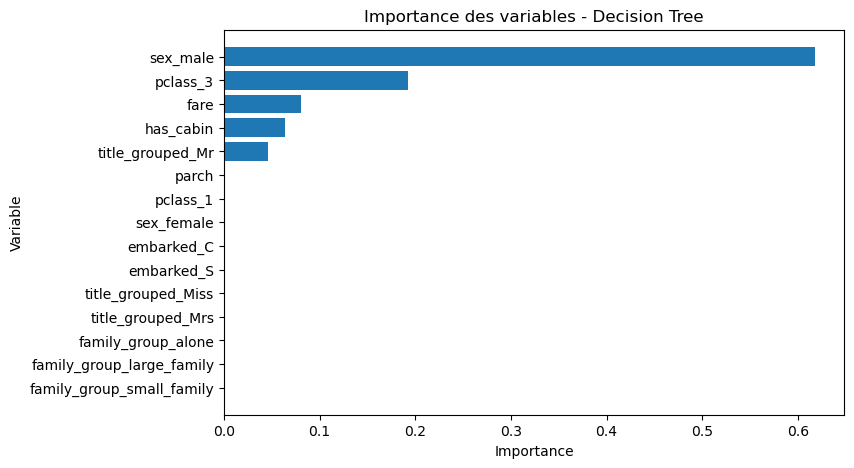

In [25]:
plt.figure(figsize=(8, 5))
plt.barh(importance_df["variable"], importance_df["importance"])
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.title("Importance des variables - Decision Tree")
plt.gca().invert_yaxis()
plt.show()

Le graphique et le tableau d'importance montrent que l'arbre de décision final utilise surtout quelques variables.

La variable la plus importante est **`sex_male`**, avec une importance d'environ **0.6175**. Elle influence donc fortement les décisions du modèle. Cela correspond à la réalité observée dans le Titanic : le sexe du passager est très lié à la probabilité de survie.

La deuxième variable la plus importante est **`pclass_3`**, avec une importance d'environ **0.1920**. Cela montre que le fait d'être en troisième classe joue aussi un rôle important dans la prédiction.

Les autres variables réellement utilisées sont **`fare`** avec **0.0804**, **`has_cabin`** avec **0.0637** et **`title_grouped_Mr`** avec **0.0465**.

Les autres variables sélectionnées par `SelectKBest` ont une importance de **0** dans l'arbre final. Cela ne veut pas dire qu'elles sont inutiles en général, mais simplement que cet arbre de décision, limité à une profondeur de 3, ne les utilise pas dans ses règles finales.

Le modèle est donc assez simple et interprétable : il fonde principalement ses décisions sur le sexe, la classe, le prix du billet, la présence d'une cabine et le titre `Mr`.

## 15. Comparaison avec les résultats précédents

Dans les notebooks précédents, nous avions comparé plusieurs combinaisons de sélection de variables et de modèles.

Le meilleur résultat obtenu était celui de la combinaison :

**SelectKBest + Decision Tree**

avec environ :

- Accuracy : 0.8550
- F1-score : 0.8000

Nous comparons maintenant ces résultats avec ceux obtenus dans le pipeline final.

In [26]:
previous_accuracy = 0.8550
previous_f1 = 0.8000

comparison_df = pd.DataFrame({
    "Approche": [
        "Ancien notebook : SelectKBest + Decision Tree",
        "Pipeline final : SelectKBest + Decision Tree"
    ],
    "Accuracy": [
        previous_accuracy,
        accuracy
    ],
    "F1-score": [
        previous_f1,
        f1
    ]
})

display(comparison_df)

,Approche,Accuracy,F1-score
0,Ancien notebook : SelectKBest + Decision Tree,0.855000,0.8
1,Pipeline final : SelectKBest + Decision Tree,0.854962,0.8


Les résultats du pipeline final sont pratiquement identiques à ceux obtenus dans le notebook précédent avec la combinaison **SelectKBest + Decision Tree**.

Dans l'ancien notebook, l'accuracy était d'environ **0.8550** et le F1-score de **0.8000**. Dans le pipeline final, on obtient une accuracy de **0.8550** et un F1-score de **0.8000**.

L'objectif du pipeline final n'était donc pas d'améliorer fortement le score, mais de regrouper toutes les étapes dans une structure unique, propre et réutilisable.

Le pipeline permet maintenant de partir directement du dataset brut, puis d'appliquer automatiquement toutes les étapes :
- feature engineering ;
- traitement des valeurs manquantes ;
- encodage ;
- standardisation ;
- sélection de variables ;
- modèle final.

Le résultat est donc cohérent avec les notebooks précédents, mais la démarche est maintenant plus complète et plus professionnelle.

In [27]:
final_results = pd.DataFrame({
    "Métrique": [
        "Accuracy test",
        "F1-score test",
        "F1-score moyen en validation croisée",
        "Écart-type validation croisée"
    ],
    "Valeur": [
        round(accuracy, 4),
        round(f1, 4),
        round(cv_mean, 4),
        round(cv_std, 4)
    ]
})

display(final_results)

,Métrique,Valeur
0,Accuracy test,0.8550
1,F1-score test,0.8000
2,F1-score moyen en validation croisée,0.7211
3,Écart-type validation croisée,0.0300


Le tableau final résume les performances principales du pipeline.

Le score sur le jeu de test est bon : **0.8550** en accuracy et **0.8000** en F1-score. Cela montre que le modèle fonctionne bien sur le découpage train/test utilisé.

La validation croisée donne cependant un F1-score moyen plus bas, de **0.7211**, avec un écart-type de **0.0300**. Cela indique que le score test est un peu plus favorable que la moyenne obtenue sur plusieurs découpages.

La conclusion la plus prudente est donc la suivante : le pipeline final donne de bons résultats, mais la performance la plus stable à retenir est plutôt celle de la validation croisée, autour de **0.72** en F1-score. Le score test de **0.8000** reste positif, mais il ne doit pas être interprété seul.

## 16. Conclusion

Dans ce notebook final, nous avons regroupé tout le travail réalisé sur le dataset Titanic dans un pipeline complet.

Nous avons commencé par reprendre le feature engineering réalisé dans le notebook de preprocessing. Cela nous a permis de créer de nouvelles variables comme `title_grouped`, `has_cabin`, `family_size` et `family_group`.

Ensuite, nous avons intégré le traitement des valeurs manquantes, l'encodage des variables catégorielles, la standardisation des variables numériques, la sélection de variables avec `SelectKBest` et le modèle final `DecisionTreeClassifier` dans un seul pipeline `sklearn`.

Le modèle final obtient une accuracy de **0.8550** et un F1-score de **0.8000** sur le jeu de test. Ces résultats sont cohérents avec ceux obtenus dans les notebooks précédents avec la combinaison **SelectKBest + Decision Tree**.

L'analyse détaillée montre cependant que le score test est plus élevé que le F1-score moyen en validation croisée, qui est de **0.7211**. Cela signifie que le jeu de test est probablement un peu favorable. Pour évaluer la stabilité du modèle, la validation croisée donne donc une estimation plus prudente.

La comparaison train/test et la courbe d'apprentissage ne montrent pas de surapprentissage important. Le modèle n'obtient pas un score beaucoup plus élevé sur les données d'entraînement que sur les données de test ou de validation.

Le modèle s'appuie principalement sur quelques variables : `sex_male`, `pclass_3`, `fare`, `has_cabin` et `title_grouped_Mr`. Cela rend l'arbre de décision assez simple à interpréter.

Le pipeline final permet donc de passer d'une série de notebooks séparés à une solution plus propre, plus structurée et plus facilement réutilisable, tout en conservant les performances obtenues lors des étapes précédentes.

## 17. Sauvegarde du pipeline final

Pour terminer, nous pouvons sauvegarder le pipeline final dans un fichier `.pkl`.

Un fichier `.pkl` est une sauvegarde du pipeline entraîné. Il contient donc le prétraitement, la sélection de variables et le modèle final déjà entraîné.

Cela permettrait de réutiliser le pipeline plus tard sans devoir relancer tout l'entraînement. Ce fichier n'est pas un résultat à interpréter comme une métrique : c'est surtout une sauvegarde technique du modèle final.

In [28]:
import joblib

joblib.dump(final_pipeline, "titanic_final_pipeline.pkl")

print("Pipeline sauvegardé dans le fichier : titanic_final_pipeline.pkl")

Pipeline sauvegardé dans le fichier : titanic_final_pipeline.pkl
